<div class="alert" style="background-color:#3643BA;">
    <strong><H1 style="text-align:center; color: white;">CUSTOMER CHURN PREDICTION</H1></strong>
</div>

---
This is just a sample code to learn the implementation of **Deep Learning Algorithms** using **Tesorflow** and **Keras**

## 1. Importing Necessary Libraries

---
Importing all the necessary libraries that would be required to manipulation of the dataset along with visualizing the graphs

In [2]:
#importing necessary libraries

#libraries for data manipulation
import pandas as pd
import numpy as np

#library for visualisation
import matplotlib.pyplot as plt

#libraries from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#libraries for tensorflow
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input


## 2. Reading The Dataset

---
Read the dataset from the local path (In this case the data is stored in the **./Data** folder)

In [2]:
#reading dataset and storing the table as a dataframe

df = pd.read_csv('/Users/mac-UPANDE01/Desktop/Personal/Projects/Machine_Learning_Practice/Deep Learning/Data/Churn_Modelling.csv')

In [3]:
#displaying the data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
#analysing the shape of the dataset
print("Number of rows in the Dataset: {}\nNumber of columns in the dataset:{}".format(df.shape[0], df.shape[1]))

Number of rows in the Dataset: 10000
Number of columns in the dataset:14


In [5]:
#to check the datatype and missing values in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
#check for duplicated rows
print("Does it have duplicated row: {}\nNumber of duplicated rows : {}".format(df.duplicated().any(),df.duplicated().sum()))

Does it have duplicated row: False
Number of duplicated rows : 0


As we can see there is a column **"RowNumber"** and this of no use to us, hence we'll remove it from our further analysis. This is a sequential number, and if required we can generate it later.

## 3. Data Cleaning

---
Cleaning the dataset for furhter Analysis or Implementation

In [7]:
#dropping RowNumber from the table and storing the updated table in the same variable by using 'inplace=True'
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 4. EDA (BASIC ANALYSIS)

---
Doing a basic analysis of the dataset

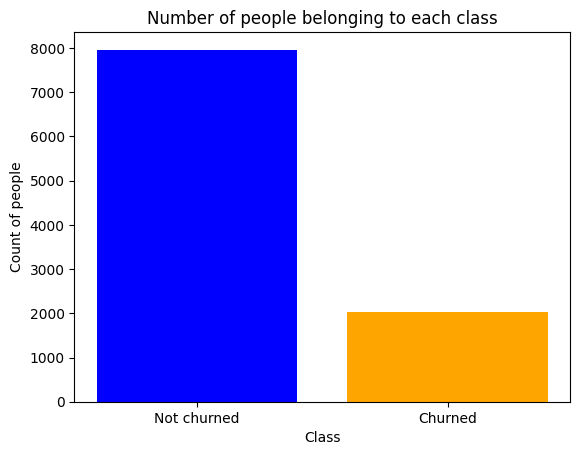

In [9]:
class_counts = df['Exited'].value_counts()
plt.bar(class_counts.index, class_counts.values, color = ['blue', 'orange'])

#add labels and title
plt.xlabel('Class')
plt.ylabel('Count of people')
plt.title('Number of people belonging to each class')
plt.xticks([0, 1], ['Not churned', 'Churned'])  # Customize the x-axis labels

#display the plot
plt.show()

It's a problem of Imbalanced Dataset. However, this notebook is just to learn the process of Implementation of Algorithm so we're not going to focus more on the EDA 

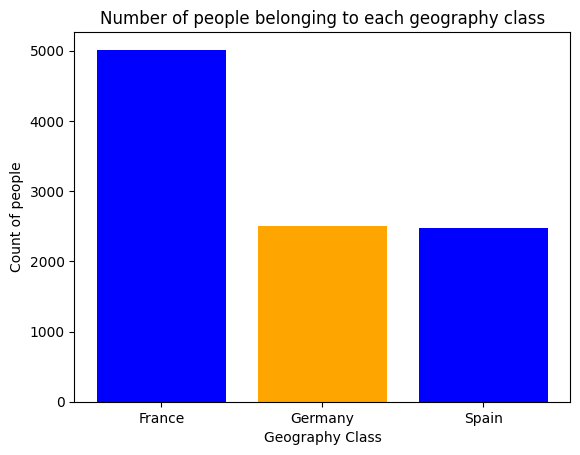

In [10]:
geo_class_counts = df['Geography'].value_counts()
plt.bar(geo_class_counts.index, geo_class_counts.values, color = ['blue', 'orange'])

#add labels and title
plt.xlabel('Geography Class')
plt.ylabel('Count of people')
plt.title('Number of people belonging to each geography class')
plt.xticks(['France', 'Germany', 'Spain'])  # Customize the x-axis labels

#display the plot
plt.show()

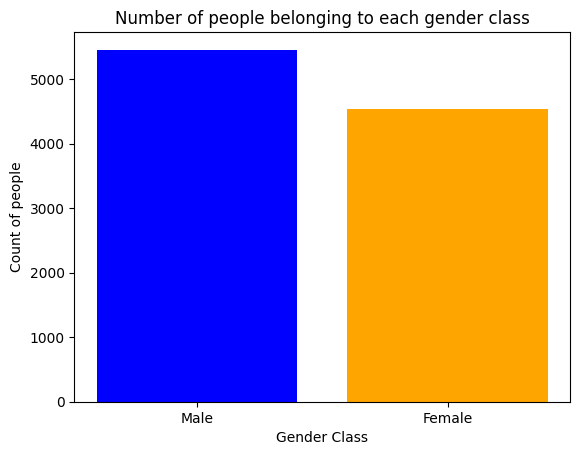

In [11]:
gender_class_counts = df['Gender'].value_counts()
plt.bar(gender_class_counts.index, gender_class_counts.values, color = ['blue', 'orange'])

#add labels and title
plt.xlabel('Gender Class')
plt.ylabel('Count of people')
plt.title('Number of people belonging to each gender class')
plt.xticks(['Male', 'Female'])  # Customize the x-axis labels

#display the plot
plt.show()

## 5. DATA WRANGLING

---
Data Manipulation

In [12]:
#converting the categorical column to numerical
df = pd.get_dummies(df, columns=['Geography', 'Gender'], dtype=int, drop_first=True)

## 6. DATA SPLIT INTO TRAIN & TEST

---
Splitting the data into train and test

In [13]:
X= df.drop(columns=['Exited'])
y = df['Exited']

#splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

## 7. DATA SCALING

---
Scaling the Dataset to bring all the numbers on the same scale

In [14]:
#creating an object
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

## 8. APPLYING ALGORITHM

---
Applying ML Algorithm on the dataset for classification using Keras and Tensorflow

In [16]:
#building a sequential model
model = Sequential()

model.add(Input(shape=(11,)))
model.add(Dense(11, activation='relu'))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [17]:
#summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#compiling a model
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [19]:
#training the model
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.7377 - loss: 0.5874 - val_accuracy: 0.7975 - val_loss: 0.4943
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 0.7998 - loss: 0.4734 - val_accuracy: 0.8069 - val_loss: 0.4491
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.8129 - loss: 0.4402 - val_accuracy: 0.8075 - val_loss: 0.4311
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.8108 - loss: 0.4326 - val_accuracy: 0.8006 - val_loss: 0.4237
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.8189 - loss: 0.4201 - val_accuracy: 0.8056 - val_loss: 0.4188
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - accuracy: 0.8225 - loss: 0.4156 - val_accuracy: 0.8044 - val_loss: 0.4121
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.8247 - loss: 0.4040 - val_accuracy: 0.8125 - val_loss: 0.4042
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.8288 - loss: 0

In [20]:
#checking the weights & biases of the 0th layer of the architecture
model.layers[0].get_weights()

[array([[-1.90706104e-02, -3.11732702e-02,  3.56748372e-01,
          3.27442080e-01, -2.25522630e-02,  1.94958419e-01,
         -1.16845287e-01,  4.40864041e-02, -9.87278521e-02,
          2.48939618e-02,  2.93824673e-01],
        [ 2.62806982e-01, -2.00268589e-02,  9.18148383e-02,
         -3.52362096e-01,  9.36468765e-02, -7.32744932e-01,
         -7.19767570e-01,  1.73436597e-01,  6.50585949e-01,
          2.60111153e-01, -5.28521538e-01],
        [ 7.35541284e-02, -9.52241719e-02,  1.00670800e-01,
         -2.38369986e-01,  5.40310860e-01, -1.25048280e-01,
          7.65395060e-04, -5.43465793e-01, -4.19063747e-01,
         -8.58389586e-02, -1.25960022e-01],
        [ 6.27524137e-01, -9.59741533e-01,  2.17533037e-02,
         -1.93700597e-01, -3.73027921e-01, -2.76908904e-01,
         -6.64613426e-01, -6.37865305e-01, -2.76518732e-01,
         -3.08192611e-01,  1.18082486e-01],
        [ 1.29344761e-01, -1.01283896e+00, -7.91975915e-01,
          1.23962450e+00,  1.36371022e-02,  

In [21]:
#prediction on the test set
y_log =  model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step


In [22]:
y_pred =np.where(y_log>0.5, 1, 0)

In [23]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

## 8. ACCURACY OF THE MODEL

---
Checking the accuracy of the model 

In [24]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8615

In [25]:
history.history

{'accuracy': [0.7745312452316284,
  0.8021875023841858,
  0.8131250143051147,
  0.8154687285423279,
  0.8170312643051147,
  0.8209375143051147,
  0.8237500190734863,
  0.8293750286102295,
  0.8399999737739563,
  0.8485937714576721,
  0.8501562476158142,
  0.8539062738418579,
  0.8531249761581421,
  0.8539062738418579,
  0.856249988079071,
  0.8575000166893005,
  0.8570312261581421,
  0.8576562404632568,
  0.8570312261581421,
  0.8620312213897705,
  0.8587499856948853,
  0.8612499833106995,
  0.8615624904632568,
  0.859375,
  0.8609374761581421,
  0.8620312213897705,
  0.860156238079071,
  0.8607812523841858,
  0.8631250262260437,
  0.8600000143051147,
  0.8609374761581421,
  0.86328125,
  0.8606250286102295,
  0.8618749976158142,
  0.8615624904632568,
  0.8607812523841858,
  0.8609374761581421,
  0.8631250262260437,
  0.8618749976158142,
  0.8617187738418579,
  0.8612499833106995,
  0.8615624904632568,
  0.8621875047683716,
  0.862500011920929,
  0.864062488079071,
  0.8634374737739563

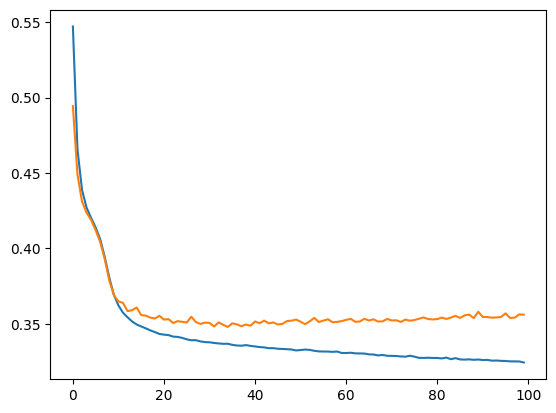

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

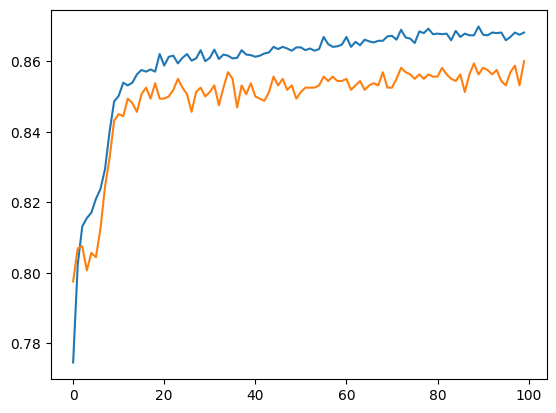

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])